# 02 – Run a D-dimensional simulation

Cell-by-cell equivalent of the script `02_run_2D.jl`.

It can run any of the three standard **2D** configurations
`:thermal`, `:weibel_norel`, `:weibel_rel`,
plus the **1D** Landau-damping family
`:undamped_l`, `:undamped_s`, `:vlasov_exp_200`, `:vlasov_exp_40`, `:damped`,
with any of the Maxwell solvers `:no_maxwell`, `:spectral`, `:sbp`,
`:holbo` (Holoborodko), `:lanczos` (Lanczos low-noise) and `:weno` (WENO-Z5).

> `:damped` is a **1D** configuration (Landau damping, `L = 7.455`, `m = 15`).
> The 2D runs (`:thermal`, `:weibel_norel`, `:weibel_rel`) go through
> `make_config`; the 1D family (including `:damped`) through `make_config_1d`.

The spatial dimension `D` is inferred from the chosen configuration and kept
constant throughout, so the core PIC loops are fully specialized.

> **Before running:** the initial particle data must exist under
> `Initial_Distributions/`. If it does not, run
> `01_generate_initial_data.ipynb` (or its `.jl` twin) first.


## 1. Environment setup

Activate the `PIC_refactor` project (the parent folder of this notebook),
load the `PIC` module, and import the plotting / IO / operator packages.
If you run the notebook from a different kernel project, set
`PIC_PROJECT_DIR` beforehand or edit the fallback below.


In [1]:
# Environment: activate the PIC project and load the module + packages
using Pkg
const PROJECT_DIR = abspath(get(ENV, "PIC_PROJECT_DIR", normpath(joinpath(pwd(), ".."))))
isdir(joinpath(PROJECT_DIR, "src")) || error("PIC_PROJECT_DIR must point to the PIC_refactor project: $PROJECT_DIR")
Pkg.activate(PROJECT_DIR)
Pkg.instantiate()

cd(PROJECT_DIR)
include(joinpath(PROJECT_DIR, "src", "PIC.jl"))
using .PIC
#ENV["GKSwstype"] = "nul"   # headless GR backend for terminal use
using Plots
using Statistics
using Base.Threads
using Printf
using FileIO, JLD2
using SummationByPartsOperators
println("project_dir = ", PROJECT_DIR)
println("nthreads = ", nthreads())


  Activating project at `~/Julia/PIC/PIC_refactor`
Precompiling packages...


project_dir = /Users/reula/Julia/PIC/PIC_refactor/

   1249.7 ms  ✓ PIC
  1 dependency successfully precompiled in 2 seconds. 140 already precompiled.
  27 dependencies precompiled but different versions are currently loaded (ArgTools, Base64, Dates, Downloads, InteractiveUtils, JuliaSyntaxHighlighting, LibCURL, LibCURL_jll, LibGit2, LibGit2_jll, LibSSH2_jll, Logging, Markdown, Mmap, MozillaCACerts_jll, NetworkOptions, OpenSSL_jll, Pkg, Printf, StyledStrings, TOML, Tar, UUIDs, Unicode, Zlib_jll, nghttp2_jll and p7zip_jll). Restart julia to access the new versions. Otherwise, 61 dependents of these packages may trigger further precompilation to work with the unexpected versions.



nthreads = 4


## 2. Configuration and solver choice

* `order`  – smoothness order of the particle shape.
* `factor` – dilation of the shape (larger ⇒ smoother fields, wider stencil).

Pick `config_name` from:
* 2D: `:thermal`, `:weibel_norel`, `:weibel_rel`
* 1D: `:undamped_l`, `:undamped_s`, `:vlasov_exp_200`, `:vlasov_exp_40`, `:damped`

and `solver_choice` from `:no_maxwell`, `:spectral`, `:sbp`, `:holbo`,
`:lanczos`, `:weno`.

> Note: the damped case is 1D Landau damping (`L = 7.455`, `m = 15`);
> `config_name = :damped` is dispatched through `make_config_1d`, the 2D
> configurations through `make_config`.


In [2]:
const order = 5
const factor = 2
#const D = 1

# -------------------------------------------------
# Choose configuration and solver
# -------------------------------------------------
# 2D options:   :thermal, :weibel_norel, :weibel_rel
# 1D options:   :undamped_l, :undamped_s, :vlasov_exp_200,
#               :vlasov_exp_40, :damped
#
config_name = :damped   # :thermal, :weibel_norel, :weibel_rel
solver_choice = :holbo     # :no_maxwell, :spectral, :sbp, :holbo, :lanczos, :weno

function load_config(name::Symbol)
    if name in (:thermal, :weibel_norel, :weibel_rel)
        return make_config(name)
    else
        return make_config_1d(name)
    end
end

cfg = load_config(config_name)
D = ndims(cfg.box)
N = cfg.N
J = cfg.J
box = cfg.box

println("Configuration: ", config_name)
println("Grid:          J = ", J)
println("Box:           ", box)
println("Data file:     ", cfg.data_name)


Configuration: damped
Grid:          J = (128,)
Box:           Box{1}([0.0], [7.455])
Data file:     par_dis_landau_norm_norel_damped_15_alp2_86_Th3


## 3. Load the initial particle data

Read the `.jld2` file written by `01_generate_initial_data` and build the
state vector `u` (particle block + field block) on the grid `g`.


In [3]:
# Load initial particle distribution
file_name = joinpath(PROJECT_DIR, "Initial_Distributions", cfg.data_name * ".jld2")
isfile(file_name) || error("Initial data not found. Run 01_generate_initial_data.jl first: $file_name")

par_dis, run_name, pars, par_f_x, box_x, par_f_p, box_p = retrieve_initial_data_D(file_name)

# Build grid and state
g = PICGrid(box, J, order)
u = make_state(g, N)
u[1:(2D*N)] .= par_dis;


## 4. Initial fields

Deposit the particle density, solve Poisson's equation for the electric
field (periodic, zero-mean), set the fields into the state, and check the
Gauss-law constraint on the freshly built initial condition.


In [4]:
# Deposit density, solve Poisson, set fields
n = zeros(size(g))
dep = DepositDensity(g, N)
deposit!(dep, u, g, n; factor=factor)
rho = n .- 1.0

E = zeros(D, size(g)...)
solve_poisson!(E, rho, g)
B = D >= 2 ? zeros(size(g)) : nothing
set_fields!(u, g, N, E, B)
coordinate_test(u, g, N)

err_max_initial, err_l2_initial = check_constraints(u, g, N, dep, factor)
println("initial  max |div E - rho| = ", err_max_initial)
println("initial  L2  |div E - rho| = ", err_l2_initial)


coordinate test passed
initial  max |div E - rho| = 2.9171883383538516e-14
initial  L2  |div E - rho| = 5.2405562110067817e-14


In [5]:
dx = differentials(g)

1-element StaticArraysCore.SVector{1, Float64} with indices SOneTo(1):
 0.0582421875

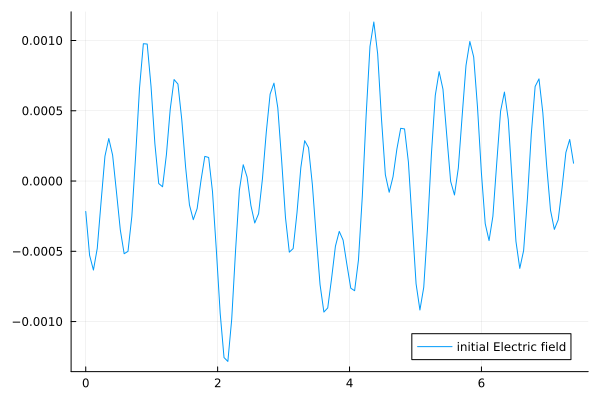

In [6]:
x_p = [dx[1]*(i-1) for i in 1:J[1]] ;
plot(x_p, E[:], label="initial Electric field")

## 5. Maxwell solver

Select how the fields are advanced in time:
* `:no_maxwell` – fields frozen (pure particle motion);
* `:spectral`   – exact FFT derivative operators;
* `:sbp`        – Summation-by-parts finite differences on a periodic grid
  (derivative order 1, accuracy order 6, one operator per spatial axis);
* `:holbo`      – Holoborodko finite-difference derivative operators
  (derivative order 1, accuracy order 4, `stencil_width = 11`);
* `:lanczos`    – Lanczos low-noise derivative operators
  (derivative order 1, accuracy order 4, `stencil_width = 11`);
* `:weno`       – 5th-order WENO-Z scheme with Lax–Friedrichs flux splitting
  (nonlinear, shock-capable; see `src/weno.jl`).


In [7]:
# Choose Maxwell solver
# Options: :no_maxwell, :spectral, :sbp, :holbo, :lanczos, :weno
derivative_order = 1
accuracy_order = 6
const stencil_width = 11   # used by the Holoborodko / Lanczos operators

if solver_choice == :no_maxwell
    maxwell = NoMaxwell{D}()
    suffix = "no_maxwell"
elseif solver_choice == :spectral
    maxwell = SpectralMaxwell(g)
    suffix = "spectral"
elseif solver_choice == :sbp
    Dops = ntuple(d -> periodic_derivative_operator(derivative_order=derivative_order,
                                                    accuracy_order=accuracy_order,
                                                    xmin=box.lo[d], xmax=box.hi[d], N=J[d]), D)
    maxwell = SBPMaxwell(Dops)
    suffix = "sbp"
elseif solver_choice == :holbo
    Dops = ntuple(d -> periodic_derivative_operator(Holoborodko2008(); derivative_order=1,
                                                    accuracy_order=4, stencil_width=stencil_width,
                                                    xmin=box.lo[d], xmax=box.hi[d], N=J[d]), D)
    maxwell = HolboMaxwell(Dops)
    suffix = "holbo"
elseif solver_choice == :lanczos
    Dops = ntuple(d -> periodic_derivative_operator(LanczosLowNoise(); derivative_order=1,
                                                    accuracy_order=4, stencil_width=stencil_width,
                                                    xmin=box.lo[d], xmax=box.hi[d], N=J[d]), D)
    maxwell = LanczosMaxwell(Dops)
    suffix = "lanczos"
elseif solver_choice == :weno
    maxwell = WENOMaxwell{D}()
    suffix = "weno"
else
    error("unknown solver_choice = $solver_choice (use :no_maxwell, :spectral, :sbp, :holbo, :lanczos, or :weno)")
end

"holbo"

## 6. RHS parameters and output file

Build the right-hand-side parameter object (with the chosen Maxwell solver),
pre-allocate the RK4 step workspace, and decide where results go.


In [8]:
p = RHSParams(g, N; factor=factor, maxwell=maxwell)
ws = StepWorkspace(u)

run_name_full = "$(cfg.run_name)_$(suffix)_o$(order)"
out_file = joinpath(PROJECT_DIR, "Results", run_name_full * ".jld2")
mkpath(dirname(out_file))
isfile(out_file) && rm(out_file)

println("Running with solver: ", solver_choice)
println("Output: ", out_file)


Running with solver: holbo
Output: /Users/reula/Julia/PIC/PIC_refactor/Results/landau_1d_damped_L_7.455_J_128_m_15_Th3_alp2_holbo_o5.jld2


## 7. Evolution parameters

Time span `t_i → t_f`, `M` total snapshots, `M_g` saved grid checkpoints
(1-in-`M` snapshots actually stored to disk), and the RK4 step `dt`.
The last line shows `dt` against the smallest grid spacing (CFL indicator).


In [9]:
# Evolution parameters
t_i = 0.0
t_f = 0.10
M = 11
M_g = 10
dt = (t_f - t_i) / (M - 1)
@show dt, minimum(differentials(g)), dt / minimum(differentials(g))

# Save metadata and initial averages
save(out_file, Dict(
    "run_name" => run_name_full,
    "par_grid" => (N, J, box, order),
    "par_evolv" => (t_i, t_f, M, M_g, dt)
))
save_averages(out_file, 1, u, g, N; dep=dep, factor=factor)


(dt, minimum(differentials(g)), dt / minimum(differentials(g))) = (0.01, 0.0582421875, 0.17169684775318578)


5.2405562110067817e-14

## 8. Time integration (RK4)

Advance `u` with 4th-order Runge–Kutta. Every `out_every` steps the
averages are appended to the output file and the Gauss constraint and
total energy are printed.


In [10]:
# Time integration with RK4
let t = t_i
    out_every = div(M - 1, M_g - 1)
    for k in 2:M
        RK4_step!(rhs!, u, t, dt, p; ws=ws)
        t += dt
        if (k - 1) % out_every == 0
            j = (k - 1) ÷ out_every + 1
            save_averages(out_file, j, u, g, N; dep=dep, factor=factor)
            EK, EE = total_energy(u, g, N)
            err_max, err_l2 = check_constraints(u, g, N, dep, factor)
            println("j = ", j, "  t = ", round(t, digits=3),
                    "  E_total = ", EK + EE,
                    "  conts_max = ", err_max,
                    "  conts_L2 = ", err_l2)
        end
    end
end


j = 2  t = 0.01  E_total = 0.0037308044962497916  conts_max = 4.4325253311111926e-6  conts_L2 = 3.523944811655066e-6
j = 3  t = 0.02  E_total = 0.003730804496249591  conts_max = 8.783882524261132e-6  conts_L2 = 7.068802487440058e-6
j = 4  t = 0.03  E_total = 0.0037308044962501017  conts_max = 1.305082637429185e-5  conts_L2 = 1.063421679781592e-5
j = 5  t = 0.04  E_total = 0.003730804496250257  conts_max = 1.723037915410166e-5  conts_L2 = 1.4219653266222134e-5
j = 6  t = 0.05  E_total = 0.003730804496249853  conts_max = 2.131982605675028e-5  conts_L2 = 1.7824356520180302e-5
j = 7  t = 0.06  E_total = 0.0037308044962499226  conts_max = 2.5316604113473743e-5  conts_L2 = 2.1447320292998744e-5
j = 8  t = 0.07  E_total = 0.0037308044962502695  conts_max = 2.9218274866795158e-5  conts_L2 = 2.5087268089833623e-5
j = 9  t = 0.08  E_total = 0.0037308044962498683  conts_max = 3.3022565134702676e-5  conts_L2 = 2.874264545006384e-5
j = 10  t = 0.09  E_total = 0.003730804496250055  conts_max = 3.672

## 9. Final constraint check

Gauss-law residual at the end of the run.


In [11]:
err_max_final, err_l2_final = check_constraints(u, g, N, dep, factor)
println("final    max |div E - rho| = ", err_max_final)
println("final    L2  |div E - rho| = ", err_l2_final)
println("Done. Output: ", out_file)


final    max |div E - rho| = 4.0586571505855946e-5
final    L2  |div E - rho| = 3.6092009969090806e-5
Done. Output: /Users/reula/Julia/PIC/PIC_refactor/Results/landau_1d_damped_L_7.455_J_128_m_15_Th3_alp2_holbo_o5.jld2


## 10. Final density snapshot

Deposit the density once more and display it (1D: line plot, 2D: surface).

> With `GKSwstype = "nul"` the figure is not shown interactively; drop that
> line in cell 1 (or use an inline-capable backend) to see it here.


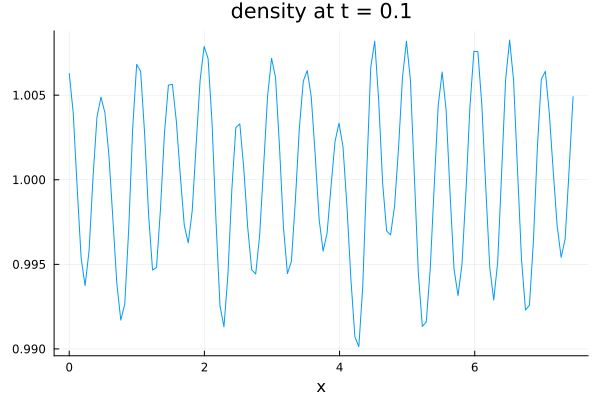

In [12]:
# Final density snapshot
deposit!(dep, u, g, n; factor=factor)
if D == 1
    plot(range(box.lo[1], box.hi[1], length=length(n)), n,
         title="density at t = $(t_f)", xlabel="x", label=false)
elseif D == 2
    surface(n, title="density at t = $(t_f)")
end


## 11. Weak-form Gauss-law checks

Sample `N_test` centers `x0` and evaluate the weak constraint
`∫ E·∇φ dV = ∫ ρ φ dV` for a compact test function `φ` of power `p` and
support `r0_frac × min(Δbox)`. The average of the normalized errors is
printed at the end.

> Note: `p` is intentionally reused (it held the `RHSParams` above); this
> reassignment only matters after the time loop has finished.


In [13]:
# Weak constraint checks
p = 4
r0_frac = 0.1
N_test = 100
x0 = [box.lo .+ rand(length(box)) .* extent(box) for _ in 1:N_test]
if D == 2
    scatter([x[1] for x in x0], [x[2] for x in x0],
        xlabel="x", ylabel="y", label="x0", aspect_ratio=:equal)
end

weak_checks = [check_constraints_weak(u, g, N, dep, factor, x, r0_frac, p)[3] for x in x0]
@show sum(weak_checks) / length(weak_checks)


sum(weak_checks) / length(weak_checks) = 3.3219267658534377e-6


3.3219267658534377e-6